# Análisis de clustering para la identificación de perfiles financieros de las IPS en Colombia

##### Objetivo : Aplicar tecnicas de mineria de datos para para identificar y analizar grupos de Instituciones Prestadoras de Servicios de Salud (IPS) en Colombia con comportamientos financieros y operativos similares, a partir de variables económicas, administrativas y de cobertura.

## 1. Carga del Dataset y exploracion inicial

In [1]:
# importar librerias necesarias para carga de datas
import pandas as pd

In [2]:
# cargar y leer dataset
df = pd.read_csv("../Datas/ips_info_2023.csv")
df.tail() # 5530 datos

,NumeroIdentificacion,NombrePrestador,NaturalezaJuridica,ESE,DepartamentoPrestador,MunicipioCode,MunicipioPrestador,CantMunicipios,CantSedes,ACTIVOS,RankActivos,PASIVOS,PATRIMONIO,INGRESOS,RankIngresos,GASTOS,COSTOS,UTILIDADES,PERIODO,MargenNeto%
5525,901455999,METRISALUD IPS SAS,Privada,NO,BOGOTÁ D.C,11001,BOGOTÁ,1,1,1074666640,3387,117477812,957188828,1866585,5526,39721397,0,-37854812,2023,"-2028,03"
5526,900096797,CENTRO DE DERMATOLOGIA Y CIRUGIA DERMATOLOGICA...,Privada,NO,BOGOTÁ D.C,11001,BOGOTÁ,1,1,1267599,5529,250971,1016628,1777882,5527,882047,794089,101746,2023,"5,72"
5527,811038083,FUNDACIÓN ARCA MUNDIAL,Privada,NO,ANTIOQUIA,5001,MEDELLÍN,1,1,1460001,5528,131556,1328445,1368381,5528,1274374,0,94007,2023,"6,87"
5528,900594892,VACUNARTE LJC SAS,Privada,NO,META,50001,VILLAVICENCIO,1,1,20321000,5490,450000,19871000,1000000,5529,950000,180000,-130000,2023,-13
5529,901444105,UNIDAD DE FISIOTERAPIA Y REHABILITACION INTEGR...,Privada,NO,CAQUETÁ,18001,FLORENCIA,1,1,19010000,5495,10000,19000000,1000000,5530,490000,500000,10000,2023,1


#### Analisis
##### Se identifica que dataset reune informacion financiera y operativa de las IPS en Colombia durante el periodo 2023, cada fila representando una institucion prestadora de servicios de salud

In [3]:
# imprimir las columnas y el tipo de varibles que tiene el dataset
print(df.info())
print(df.dtypes)
print(print(df.isnull().sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5530 entries, 0 to 5529
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   NumeroIdentificacion   5530 non-null   int64 
 1   NombrePrestador        5530 non-null   object
 2   NaturalezaJuridica     5530 non-null   object
 3   ESE                    5530 non-null   object
 4   DepartamentoPrestador  5530 non-null   object
 5   MunicipioCode          5530 non-null   int64 
 6   MunicipioPrestador     5530 non-null   object
 7   CantMunicipios         5530 non-null   int64 
 8   CantSedes              5530 non-null   int64 
 9   ACTIVOS                5530 non-null   int64 
 10  RankActivos            5530 non-null   int64 
 11  PASIVOS                5530 non-null   int64 
 12  PATRIMONIO             5530 non-null   int64 
 13  INGRESOS               5530 non-null   int64 
 14  RankIngresos           5530 non-null   int64 
 15  GASTOS               

#### Analisis
##### Se evidencia que el dataset contiene 5530 registros y varibales, ademas de no existir valores nulos dentro de la data. Para un mejor analisis se le tendra que hacer una conversion a la varibale MargenNeto%. ya que esta como texto, esta variable sera fundamental para el estudio.

## 2. Tratamiento de variables

In [4]:
# Convertir a datos numericos
for col in df:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
#mostramos el contenido mde la columna, se puede ver que es tipo object
df["MargenNeto%"]

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
5525     NaN
5526     NaN
5527     NaN
5528   -13.0
5529     1.0
Name: MargenNeto%, Length: 5530, dtype: float64

In [6]:
# rellenar los valores nulos
df = df.fillna(df.median())

In [7]:
# verificamos ahora si todas las variables 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5530 entries, 0 to 5529
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   NumeroIdentificacion   5530 non-null   int64  
 1   NombrePrestador        0 non-null      float64
 2   NaturalezaJuridica     0 non-null      float64
 3   ESE                    0 non-null      float64
 4   DepartamentoPrestador  0 non-null      float64
 5   MunicipioCode          5530 non-null   int64  
 6   MunicipioPrestador     0 non-null      float64
 7   CantMunicipios         5530 non-null   int64  
 8   CantSedes              5530 non-null   int64  
 9   ACTIVOS                5530 non-null   int64  
 10  RankActivos            5530 non-null   int64  
 11  PASIVOS                5530 non-null   int64  
 12  PATRIMONIO             5530 non-null   int64  
 13  INGRESOS               5530 non-null   int64  
 14  RankIngresos           5530 non-null   int64  
 15  GAST

## 3. Eleccion de varibales para el clustering

In [8]:
# se eligen las variables que se van a utilizar para el clustering
variables_cluster = [
    # variables operativas
    'CantMunicipios',
    'CantSedes',
    # variables financieras
    'ACTIVOS',
    'PATRIMONIO',
    'INGRESOS',
    'UTILIDADES',
    # indicador de rentabilidad
    'MargenNeto%'
]

X = df[variables_cluster]
# Verificando que no existan valores nulos 
print(X.isnull().sum())

CantMunicipios    0
CantSedes         0
ACTIVOS           0
PATRIMONIO        0
INGRESOS          0
UTILIDADES        0
MargenNeto%       0
dtype: int64


#### Analisis
##### Se seleccionaron estas variables unicamente numericas para poder relacionar el desempeño financiero y operativo de las IPS

In [9]:
# vemos que los valores son muy extremos entre el minimo y el maximo de algunas columnas
# por lo que debemos realizar una trasnformacion logaritmica
X.describe()


,CantMunicipios,CantSedes,ACTIVOS,PATRIMONIO,INGRESOS,UTILIDADES,MargenNeto%
count,5530.000000,5530.000000,5.530000e+03,5.530000e+03,5.530000e+03,5.530000e+03,5530.000000
mean,1.584448,2.563291,1.956834e+10,1.053856e+10,1.908597e+10,1.214785e+09,6.032188
std,2.415999,5.794958,8.083367e+10,4.748997e+10,7.833030e+10,7.408894e+09,2.078504
min,1.000000,1.000000,1.214444e+06,-4.079620e+11,1.000000e+06,-1.292314e+11,-24.000000
25%,1.000000,1.000000,4.842593e+08,2.499762e+08,7.287338e+08,9.239574e+06,6.000000
50%,1.000000,1.000000,1.981705e+09,1.060405e+09,2.427986e+09,9.884252e+07,6.000000
75%,1.000000,2.000000,7.694398e+09,4.483227e+09,8.303602e+09,5.105489e+08,6.000000
max,40.000000,108.000000,1.725030e+12,1.027820e+12,1.974800e+12,1.775983e+11,81.000000


## 4. Estadistica descriptiva

In [10]:
import numpy as np

In [11]:
print ("Estadistica descriptiva de los variables escogidas: ")
X.describe()


Estadistica descriptiva de los variables escogidas: 


,CantMunicipios,CantSedes,ACTIVOS,PATRIMONIO,INGRESOS,UTILIDADES,MargenNeto%
count,5530.000000,5530.000000,5.530000e+03,5.530000e+03,5.530000e+03,5.530000e+03,5530.000000
mean,1.584448,2.563291,1.956834e+10,1.053856e+10,1.908597e+10,1.214785e+09,6.032188
std,2.415999,5.794958,8.083367e+10,4.748997e+10,7.833030e+10,7.408894e+09,2.078504
min,1.000000,1.000000,1.214444e+06,-4.079620e+11,1.000000e+06,-1.292314e+11,-24.000000
25%,1.000000,1.000000,4.842593e+08,2.499762e+08,7.287338e+08,9.239574e+06,6.000000
50%,1.000000,1.000000,1.981705e+09,1.060405e+09,2.427986e+09,9.884252e+07,6.000000
75%,1.000000,2.000000,7.694398e+09,4.483227e+09,8.303602e+09,5.105489e+08,6.000000
max,40.000000,108.000000,1.725030e+12,1.027820e+12,1.974800e+12,1.775983e+11,81.000000


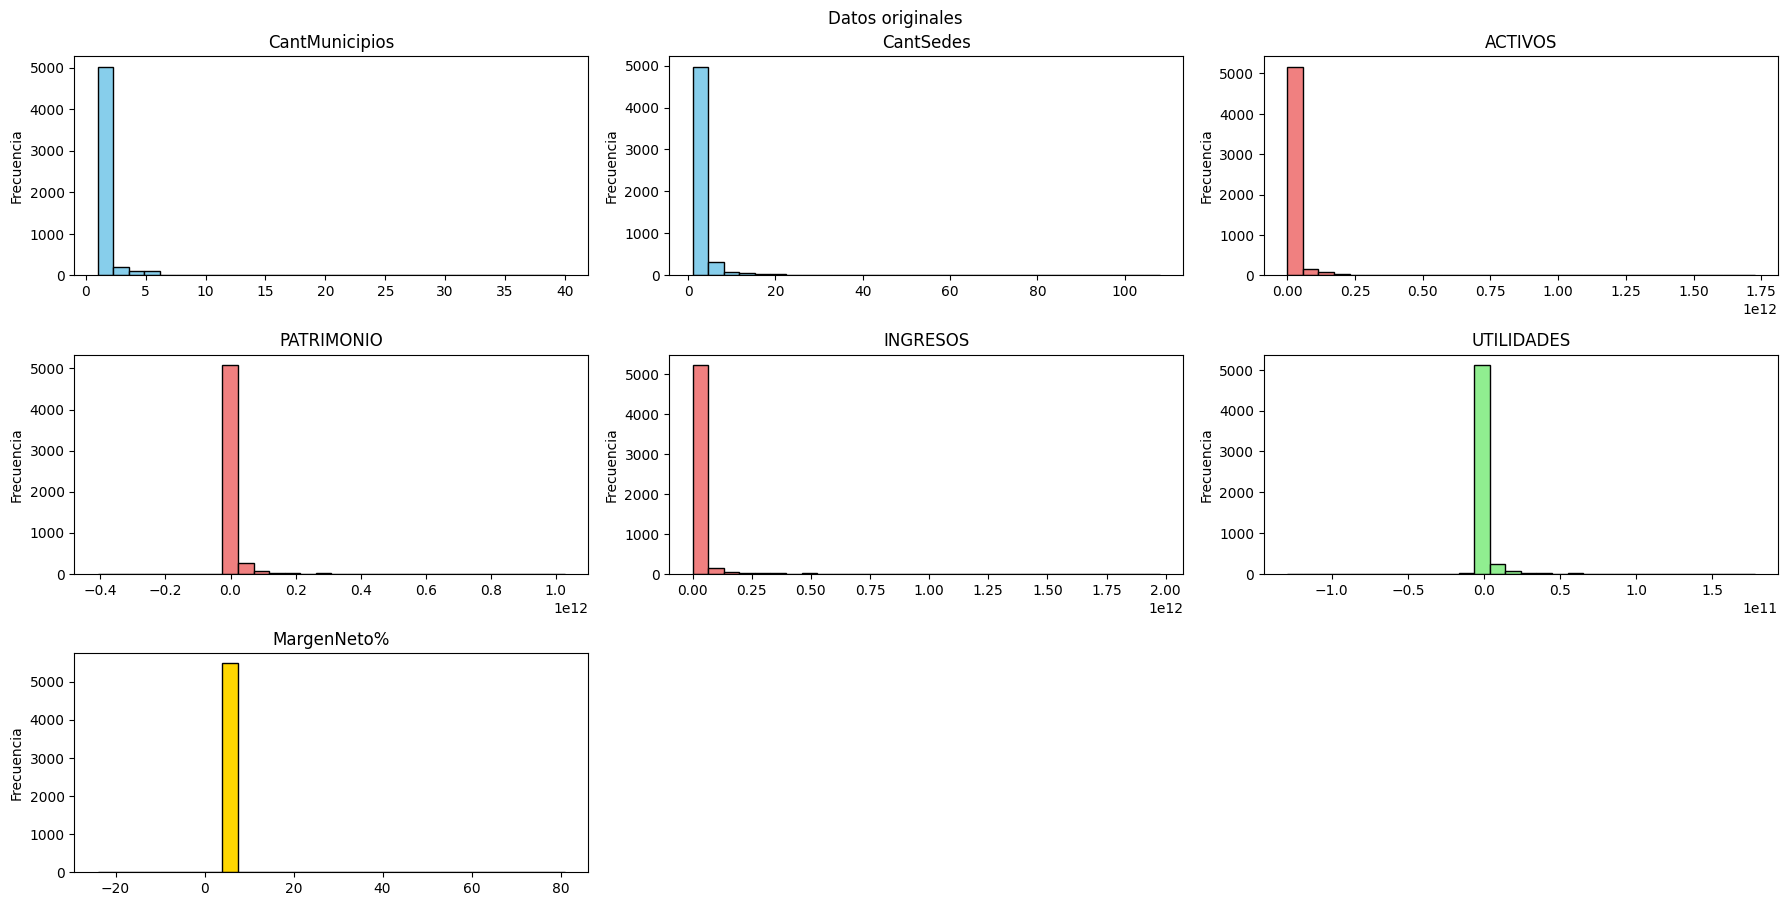

In [12]:
# histograma de valores originales
import matplotlib.pyplot as plt

# visualizacion de la normalizacion con historigrama
plt.figure(figsize=(18,12))
plt.suptitle("Datos originales")
#  colores por variables
colores = {
    # variables operativas
    'CantMunicipios': 'skyblue',
    'CantSedes': 'skyblue',
    
    # variables financieras
    'ACTIVOS': 'lightcoral',
    'PASIVOS': 'lightcoral',
    'PATRIMONIO': 'lightcoral',
    'INGRESOS': 'lightcoral',
    'GASTOS': 'lightcoral',
    'COSTOS': 'lightcoral',
    
    'UTILIDADES': 'lightgreen',
    
    'MargenNeto%': 'gold'
}
# crear histogramas
for i, columna in enumerate(X.columns, 1):
    plt.subplot(4,3,i)
    plt.hist(
        X[columna],
        bins=30,
        color=colores[columna],
        edgecolor='black'
    )
    plt.title(columna)
    plt.xlabel('')
    plt.ylabel('Frecuencia')
    
plt.tight_layout()
plt.show()

In [13]:
# vemos que hay valores son muy extremos entre el minimo y el maximo de algunas columnas
# por lo que debemos realizar una trasnformacion logaritmica

# a que variables aplicar logaritmo (solo valores positivos)
var_log = [
    'ACTIVOS',
    'INGRESOS',
]

X_log = X.copy()
X_log[var_log] = np.log1p(X_log[var_log])
X_log.describe()

,CantMunicipios,CantSedes,ACTIVOS,PATRIMONIO,INGRESOS,UTILIDADES,MargenNeto%
count,5530.000000,5530.000000,5530.000000,5.530000e+03,5530.000000,5.530000e+03,5530.000000
mean,1.584448,2.563291,21.467937,1.053856e+10,21.676623,1.214785e+09,6.032188
std,2.415999,5.794958,2.064480,4.748997e+10,1.907824,7.408894e+09,2.078504
min,1.000000,1.000000,14.009798,-4.079620e+11,13.815512,-1.292314e+11,-24.000000
25%,1.000000,1.000000,19.998131,2.499762e+08,20.406819,9.239574e+06,6.000000
50%,1.000000,1.000000,21.407223,1.060405e+09,21.610328,9.884252e+07,6.000000
75%,1.000000,2.000000,22.763758,4.483227e+09,22.839955,5.105489e+08,6.000000
max,40.000000,108.000000,28.176266,1.027820e+12,28.311488,1.775983e+11,81.000000


In [14]:
# Normalizar valores muy extremos
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

# convertir a Dataframe de neuvo
X_scaled = pd.DataFrame(X_scaled, columns=variables_cluster)

X_scaled.describe()

,CantMunicipios,CantSedes,ACTIVOS,PATRIMONIO,INGRESOS,UTILIDADES,MargenNeto%
count,5530.000000,5530.000000,5.530000e+03,5530.000000,5.530000e+03,5530.000000,5530.000000
mean,0.584448,1.563291,2.195300e-02,2.238977,2.724672e-02,2.226055,0.032188
std,2.415999,5.794958,7.464783e-01,11.218324,7.841009e-01,14.779085,2.078504
min,0.000000,0.000000,-2.674774e+00,-96.621359,-3.203609e+00,-257.984858,-30.000000
25%,0.000000,0.000000,-5.095019e-01,-0.191444,-4.946329e-01,-0.178738,0.000000
50%,0.000000,0.000000,-6.423085e-16,0.000000,-7.300679e-16,0.000000,0.000000
75%,0.000000,1.000000,4.904981e-01,0.808556,5.053671e-01,0.821262,0.000000
max,39.000000,107.000000,2.447562e+00,242.546390,2.754125e+00,354.071690,75.000000


#### Analisis
##### Aqui se evidencia una gran heterogeniedad entre las IPS, lo que indica diferencias importantes en el tamaño, cobertura y capacidad economica de las mismas 

## 5. Visualizacion de los datos

In [15]:
# importamos las librerias que necesitamos para dicha visualizacion 
import matplotlib.pyplot as plt
import seaborn as sns

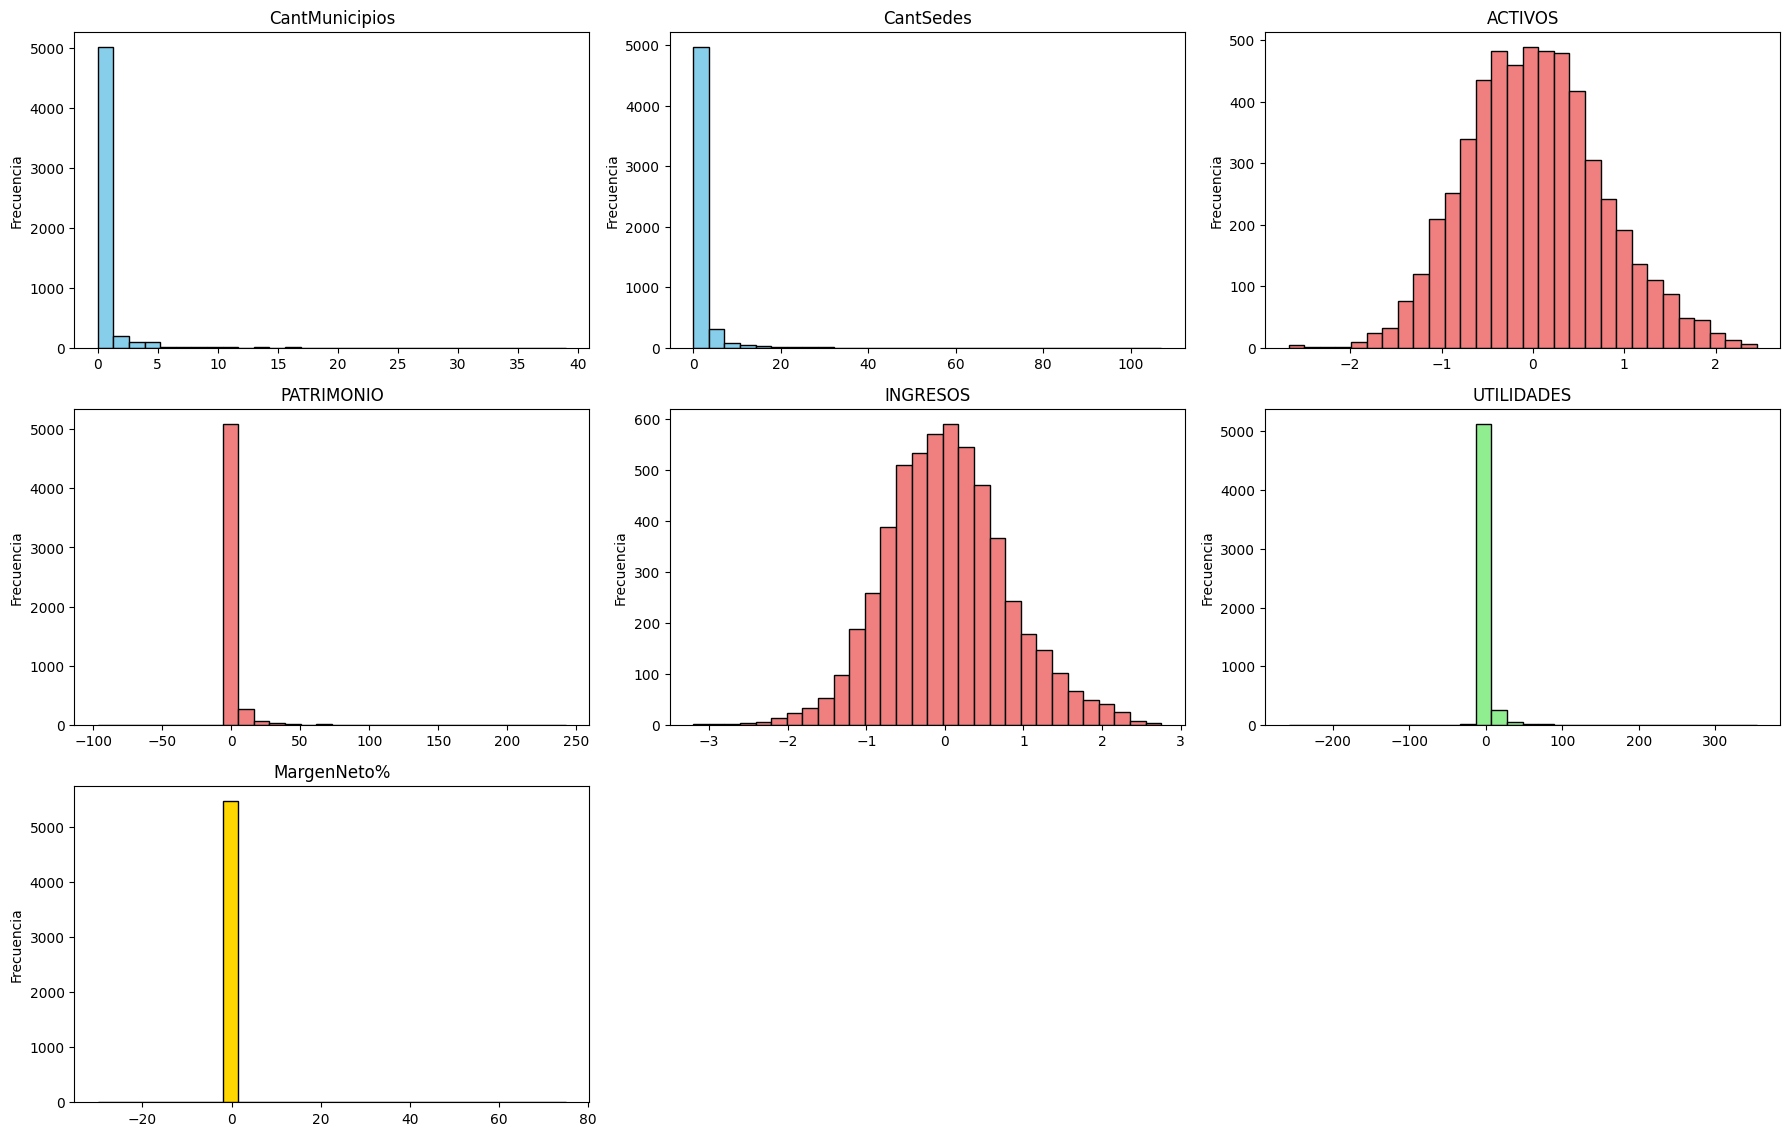

In [16]:
#Histograma con variables normalizadas
plt.figure(figsize=(18,15))
#  colores por variable
colores = {
    # variables operativas
    'CantMunicipios': 'skyblue',
    'CantSedes': 'skyblue',
    
    # variables financieras
    'ACTIVOS': 'lightcoral',
    'PASIVOS': 'lightcoral',
    'PATRIMONIO': 'lightcoral',
    'INGRESOS': 'lightcoral',
    'GASTOS': 'lightcoral',
    'COSTOS': 'lightcoral',
    
    'UTILIDADES': 'lightgreen',
    
    'MargenNeto%': 'gold'
}
# crear histogramas
for i, columna in enumerate(X_scaled.columns, 1):
    plt.subplot(4,3,i)
    plt.hist(
        X_scaled[columna],
        bins=30,
        color=colores[columna],
        edgecolor='black'
    )
    plt.title(columna)
    plt.xlabel('')
    plt.ylabel('Frecuencia')
    
plt.tight_layout()
plt.show()

#### Analisis
##### Los histogramas de las varibales dejan ver que la mayoria de varibales estan sesgadas hacia la parte derecha, indicando que muchas ips tiene desigualdad financiera, una gran cobertura regional y que muchas poseen rentabilidades pequeñas o ganancias y perdidas significativas.

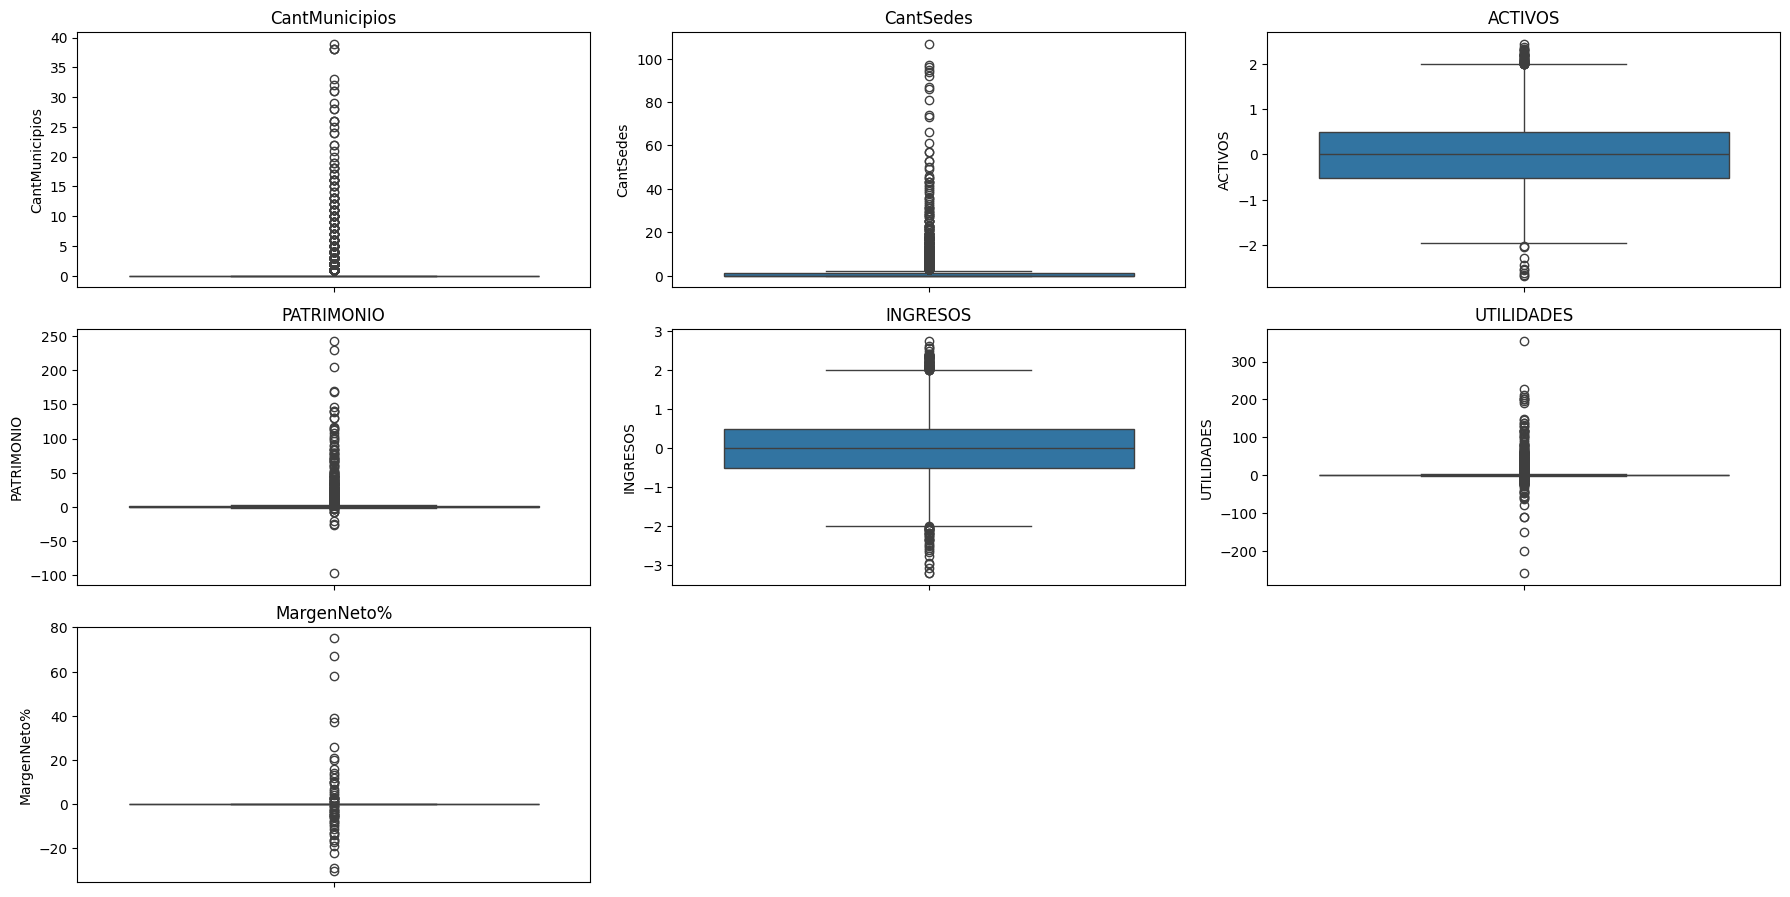

In [17]:
# Boxplots
plt.figure(figsize=(18,12))
for i, columna in enumerate(X_scaled.columns, 1):
    plt.subplot(4,3,i)
    sns.boxplot(
        y=X_scaled[columna]
    )
    plt.title(columna)
plt.tight_layout()
plt.show()

#### Analisis
##### se evidencian muchos valores atipicos, indicando que existen ips significativamente mas grandes que el resto, con niveles financieros y operativos mayores.

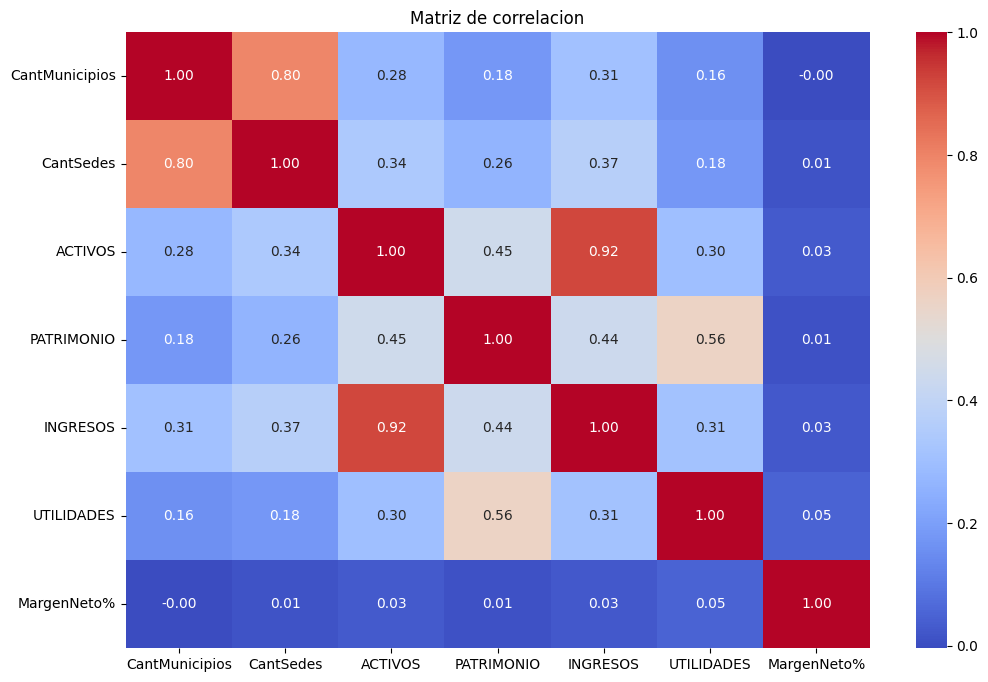

In [18]:
# Matriz de correlacion 
correlacion = X_scaled.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlacion')

# Mostrar
plt.show()

#### Analisis
##### Aqui se presentan varias correlaciones fuertes asociadas al tamaño y a la capacidad operativa de las ips, afirmando que las instituciones con mayores activos tienden a presentar mayores ingresos, costos y niveles de operacion, sin embargo, se evidencia tambien que el margen neto tiene correlacioens bajas, sugiriendo que depronto depende de factores distintos al tamaño. 


## 6. Metodo del codo

##### Este metodo es utilziado para entender y poder determinar cual es el numero de grupos que mejor se puede adaptar a nuestro modelo de analisis

In [19]:
# importamos librerias necesarias para la creacion de un modelo (cluster)
from sklearn.cluster import KMeans

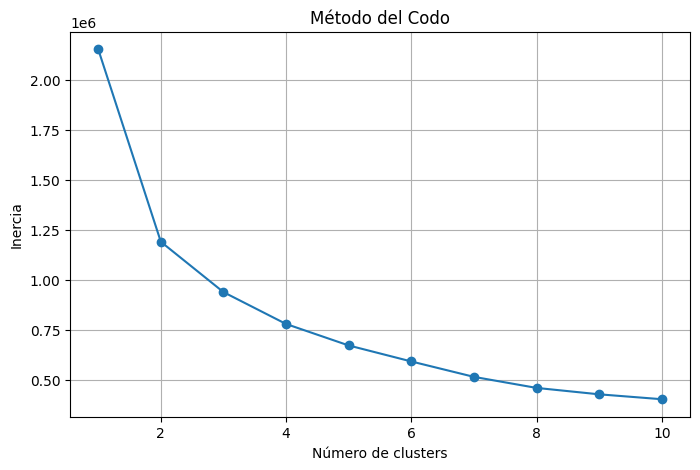

In [20]:
# lista para guardar valores de error por cada cluster
inercia = []

# para probar los diferentes n_cluster o grupos (1, 2...10 cluesters)
for k in range(1,11):
    # modelo KMeans dandole  que elija entre 10 la mejor opcion
    modelo = KMeans(
        n_clusters=k, # k como numero de grupos
        random_state=42, # un valor para que sea reproducible 
        n_init=10 # que elija entre 10 opciones la mejor (estabilidad)
    )
    # entrena el modelo, analizando datos, centroides y agrupando por ips
    modelo.fit(X_scaled)
    # guardar inercia, que tan cerca estan los datos del centro n_init
    inercia.append(modelo.inertia_) # mayor inercia = cluster mas compactos

# Grafico
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inercia, marker='o')

plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')

plt.grid()

plt.show()


### Analisis

##### El metodo del codo fue utilizado para ver graficamente los numeros de cluster mas optimo, calculando la inercia para grupos entre 1 y 10. La inercia es la suma de las distancias de cada entrenamiento con respecto a su centroide. Segun el grafico el numero mas optimo donde esta inercia se empieza a estabilizar es 2 y 3, como se ve en forma de "codo".

## 7. Clustering

In [21]:
# 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# agregar columna de cluster a las datas
X_scaled['cluster'] = kmeans.labels_
df['cluster'] = kmeans.labels_

X_scaled = pd.DataFrame(
    X_scaled,
    columns=variables_cluster
)

# Cantidad de IPS por cluster
print(df['cluster'].value_counts())

cluster
0    5342
1     153
2      35
Name: count, dtype: int64


In [22]:
# Promedios por cluster
df.groupby('cluster')[variables_cluster].mean()

,CantMunicipios,CantSedes,ACTIVOS,PATRIMONIO,INGRESOS,UTILIDADES,MargenNeto%
cluster,,,,,,,
0,1.444403,2.142456,9.947166e+09,4.811988e+09,9.857941e+09,3.420807e+08,6.023961
1,5.915033,15.228758,2.224773e+11,1.201663e+11,2.342153e+11,1.663192e+10,6.084967
2,4.028571,11.428571,6.010322e+11,4.053464e+11,4.871247e+11,6.701944e+10,7.057143


## 8. Visualizacion y analisis de clusterings

### 1. cluster por cobertura geografica (sedes y municipios donde estan)

In [43]:
# improtar libreria para mejor visualizacion y analisis de graficas
from matplotlib.pyplot import scatter

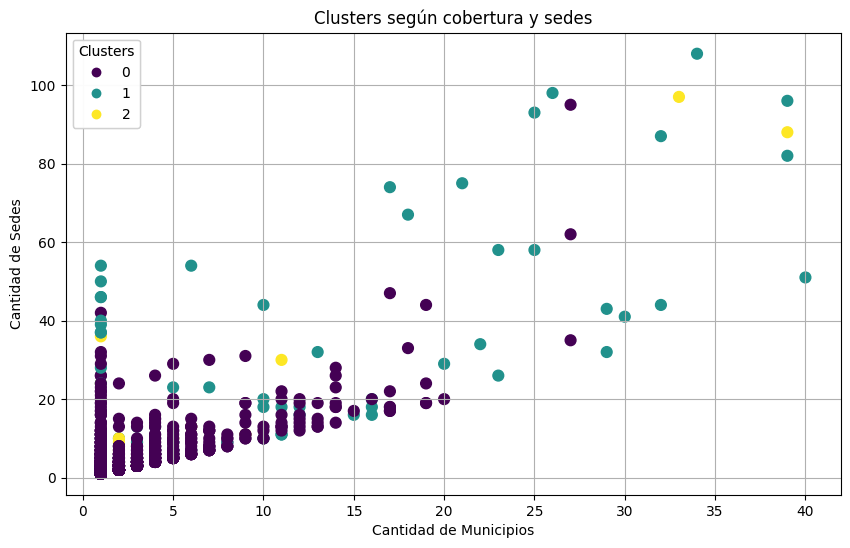

In [ ]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['CantMunicipios'],
    df['CantSedes'],
    c=df['cluster'],
    s=60
)

plt.xlabel('Cantidad de Municipios')
plt.ylabel('Cantidad de Sedes')
plt.title('Clusters según cobertura y sedes')
# clasificacion de cada cluster
legend1 = plt.legend(
    *scatter.legend_elements(),
    title='Clusters'
)

plt.gca().add_artist(legend1)
plt.grid(True)
plt.show()


### Interpretacion

##### el eje 'x' es la cantidad de municipios donde estan y el eje 'y' la canidad de sedes que tiene operando.Cluster 0 -> ubicado mayormente en la parte inferior izquierda nos dice que la mayoria de las IPS cuentan con pocas sedes, operacion mas local y una baja cobertura municipal, lo que indica que las pequeñas o regionales IPS tienen una limitada capacidad de expancion.

Cluster 1 -> muy disperso pero contando con IPS hacia la derecha y arriba lo que indica una alta cantidad de sedes operando en varios municipios, probablemente posean una mayor capacidad de antencion y recursos operativos.

Cluster 2 -> estas son muy pocas se encuentra mas disperso pero en zonas mas intermedias, indicando una cobertura regional con un crecimiento operativo moderado y una capacidad administrativa mas estable

### 2. Cluster financiero (activos e ingresos)

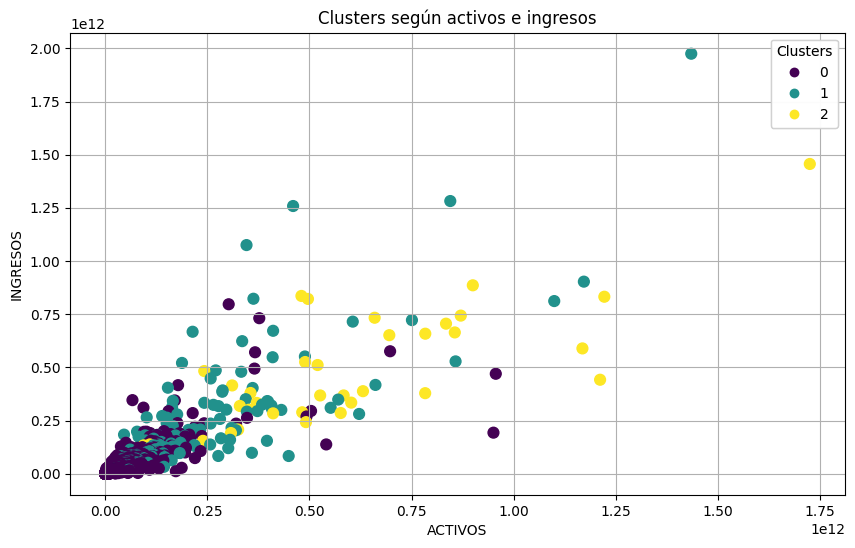

In [48]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['ACTIVOS'],
    df['INGRESOS'],
    c=df['cluster'],
    s=60
)

plt.xlabel('ACTIVOS')
plt.ylabel('INGRESOS')
plt.title('Clusters según activos e ingresos')
# clasificacion de cada cluster
legend1 = plt.legend(
    *scatter.legend_elements(),
    title='Clusters'
)
plt.gca().add_artist(legend1)

plt.grid(True)

plt.show()

### 3. Rentabilidad de la IPS (ingresos y utilidad)

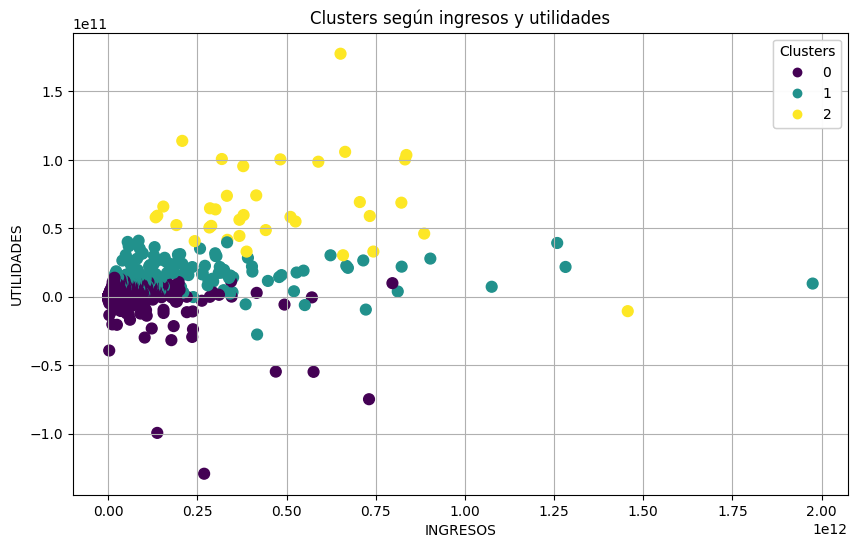

In [49]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['INGRESOS'],
    df['UTILIDADES'],
    c=df['cluster'],
    s=60
)

plt.xlabel('INGRESOS')
plt.ylabel('UTILIDADES')
plt.title('Clusters según ingresos y utilidades')

# clasificacion de cada cluster
legend1 = plt.legend(
    *scatter.legend_elements(),
    title='Clusters'
)
plt.gca().add_artist(legend1)

plt.grid(True)

plt.show()

### 4. Margen neto y su patrimonio

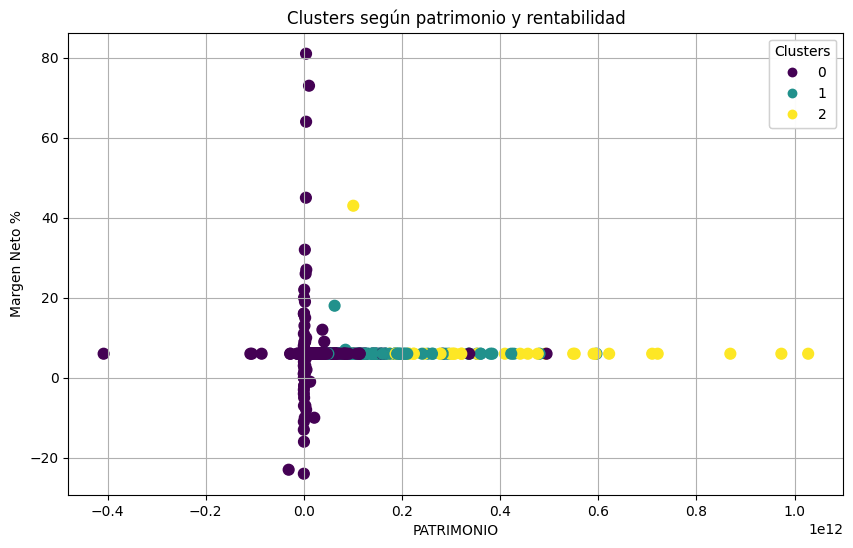

In [50]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df['PATRIMONIO'],
    df['MargenNeto%'],
    c=df['cluster'],
    s=60
)

plt.xlabel('PATRIMONIO')
plt.ylabel('Margen Neto %')
plt.title('Clusters según patrimonio y rentabilidad')
# clasificacion de cada cluster
legend1 = plt.legend(
    *scatter.legend_elements(),
    title='Clusters'
)
plt.gca().add_artist(legend1)

plt.grid(True)

plt.show()

### Esta parte nos muestra muchas mas relaciones entre variables por cluster (parecido al mapa de calor)

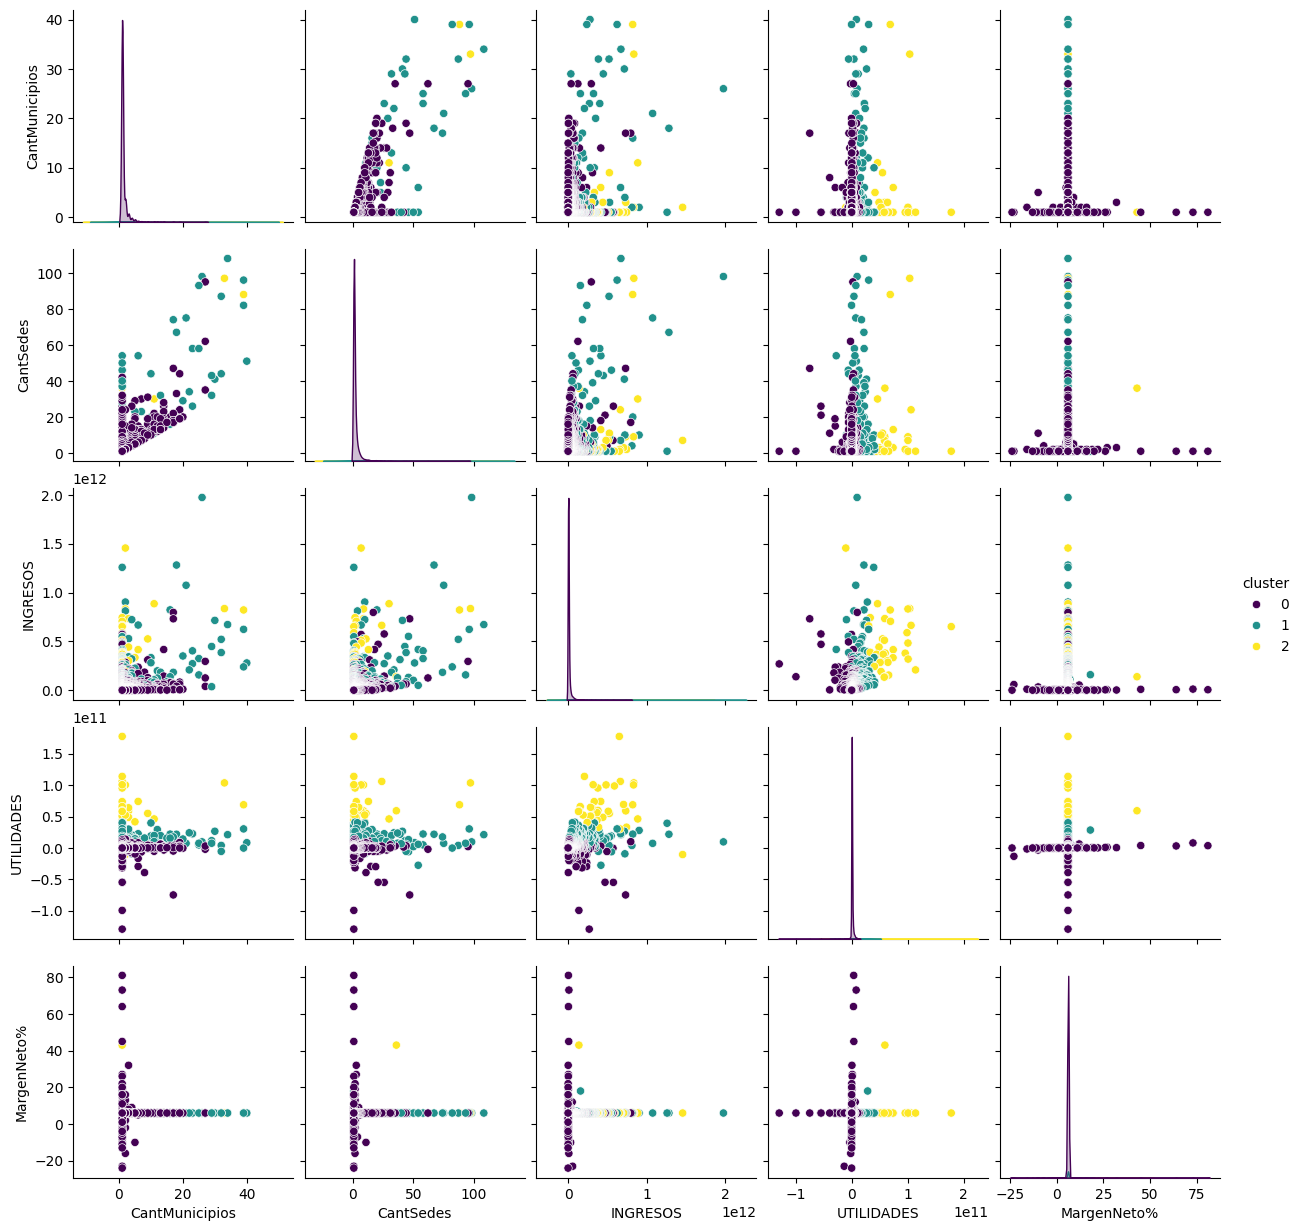

In [27]:
sns.pairplot(
    df[
        [
            'CantMunicipios',
            'CantSedes',
            'INGRESOS',
            'UTILIDADES',
            'MargenNeto%',
            'cluster'
        ]
    ],
    hue='cluster',
    palette='viridis'
)

plt.show()

In [ ]:
print("\nINTERPRETACIÓN")

for cluster in sorted(df['cluster'].unique()):

    cantidad = len(df[df['cluster'] == cluster])

    print(f"\nCluster {cluster}")
    print(f"Cantidad de IPS: {cantidad}")